<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 2 · XGBoost & Random Forest</h4>
<h1 align="center">Random Forest — Hotel Booking Demand</h1>
<p align="center"><i>Exploring what actually predicts a cancellation, before we touch a single hyperparameter</i></p>

---


## 1. The data drives the model, not the other way around

It is tempting, especially with an algorithm as forgiving as Random Forest, to skip straight
to `RandomForestClassifier(...)` and start turning knobs. Resist that urge. **No amount of
hyperparameter tuning can make a model learn a signal that isn't in the data, or that you
haven't given the model access to in a usable form.**

Before we pick `n_estimators`, `max_depth`, or anything else in `03_train_test_eval.ipynb`, we
need to answer much more basic questions with this dataset:

- Does booking far in advance (`lead_time`) actually relate to cancellation, or is that just
  received wisdom?
- Does the *type of deposit* required change cancellation behavior — and if so, by how much?
- Do certain **market segments** (direct bookings vs. online travel agents vs. corporate
  contracts) behave completely differently?
- Is there a seasonal pattern by arrival month?

If we skip this step, the most likely outcome is not "the model fails" — it's something
worse: **the model trains, produces a plausible-looking accuracy number, and we tune it for
hours without ever noticing it's optimizing the wrong thing**, or missing an obviously useful
feature because we never looked. Exploratory Data Analysis (EDA) is how we build the
intuition that lets us sanity-check every number the model produces later.

> **Working rule for this notebook:** every plot should end with a one-line answer to "so
> what does this mean for prediction?" A pretty chart that doesn't inform a modeling decision
> is decoration, not analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

df = pd.read_csv("data/hotel_bookings_clean.csv")
print(df.shape)
df.head(3)

(87396, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [2]:
df["is_canceled"].value_counts(normalize=True).rename("share").to_frame()

,share
is_canceled,
0,0.725102
1,0.274898



After deduplication, roughly **27.5%** of bookings in this dataset end in cancellation. Keep
this baseline in mind throughout: any subgroup with a cancellation rate meaningfully above or
below ~27.5% is a candidate predictive signal.



## 2. Cancellation rate by hotel

The dataset covers two properties — a Resort Hotel and a City Hotel. Do they behave
differently? If they do, `hotel` is a genuinely useful feature (which is exactly why we
one-hot encode it later), and it hints that guest behavior might differ by trip *purpose*
(leisure vs. business) as much as by any other factor.


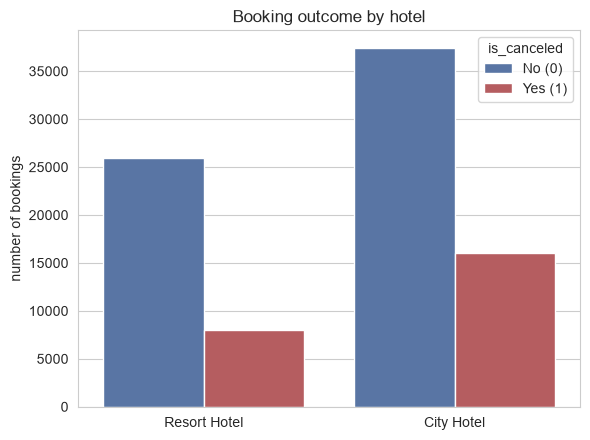

,cancellation_rate
hotel,
City Hotel,0.300386
Resort Hotel,0.234809


In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.countplot(data=df, x="hotel", hue="is_canceled", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Booking outcome by hotel")
ax.set_xlabel("")
ax.set_ylabel("number of bookings")
ax.legend(title="is_canceled", labels=["No (0)", "Yes (1)"])
plt.tight_layout()
plt.show()

df.groupby("hotel")["is_canceled"].mean().rename("cancellation_rate").to_frame()


City Hotel bookings cancel noticeably more often than Resort Hotel bookings. A plausible
story: city-hotel stays skew toward business travel and short online-travel-agent bookings,
both of which are easier to cancel or rebook than a planned resort holiday. Whatever the
underlying cause, the gap is large enough that `hotel` should clearly stay in the feature set.



## 3. Lead time vs. cancellation

`lead_time` is the number of days between the booking date and the arrival date. The common
intuition is: *the further out you book, the more chances something changes and you cancel.*
Let's check whether the data actually supports that.


C:\Users\Asus\AppData\Local\Temp\ipykernel_59800\4267350857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="is_canceled", y="lead_time", ax=axes[0], palette=["#4C72B0", "#C44E52"])


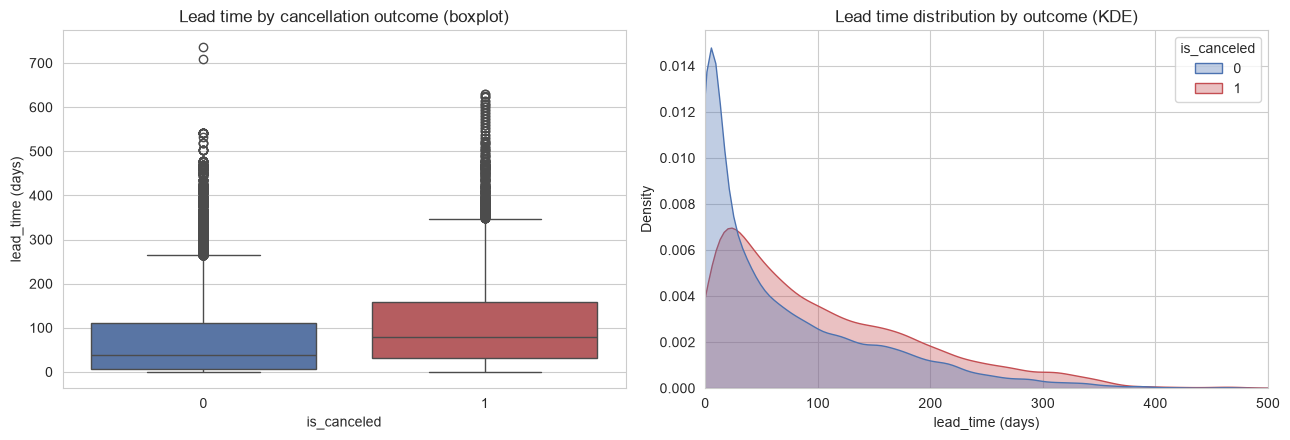

,median_lead_time
is_canceled,
0,38.0
1,80.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="is_canceled", y="lead_time", ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Lead time by cancellation outcome (boxplot)")
axes[0].set_xlabel("is_canceled")
axes[0].set_ylabel("lead_time (days)")

sns.kdeplot(data=df, x="lead_time", hue="is_canceled", common_norm=False,
            palette=["#4C72B0", "#C44E52"], fill=True, alpha=0.35, ax=axes[1])
axes[1].set_title("Lead time distribution by outcome (KDE)")
axes[1].set_xlabel("lead_time (days)")
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

df.groupby("is_canceled")["lead_time"].median().rename("median_lead_time").to_frame()


Both views tell the same story: canceled bookings have a **visibly higher median lead time**
and a fatter right tail than completed bookings. The KDE plot shows the canceled distribution
shifted and stretched further to the right — bookings made many months in advance carry more
cancellation risk than last-minute bookings, which makes intuitive sense (more time for plans
to change) and confirms `lead_time` is one of the strongest single predictors available here.



## 4. Cancellation rate by arrival month — mind the categorical ordering

`arrival_date_month` is stored as text ("January", "February", ...). If we plot it without
specifying an order, pandas/matplotlib will happily sort it **alphabetically**
("April, August, December, ..."), which destroys any seasonal pattern visually. This is a
classic, easy-to-miss mistake with categorical time features — always check whether a
category has a natural order and enforce it explicitly.


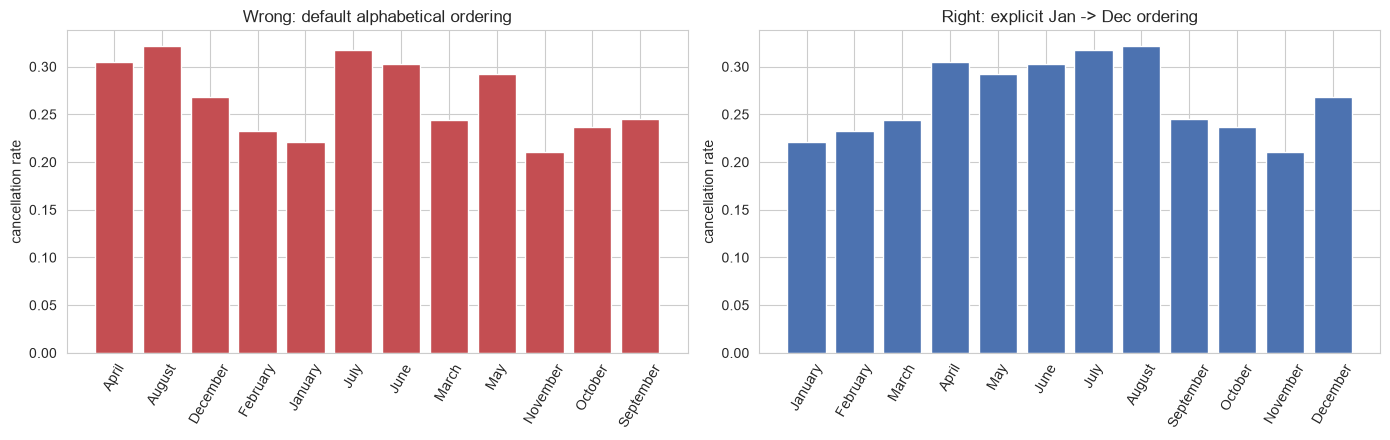

In [5]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_rate = (
    df.groupby("arrival_date_month")["is_canceled"]
      .mean()
      .reindex(month_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Wrong way: default (alphabetical) ordering
wrong_order_rate = df.groupby("arrival_date_month")["is_canceled"].mean()
axes[0].bar(wrong_order_rate.index, wrong_order_rate.values, color="#C44E52")
axes[0].set_title("Wrong: default alphabetical ordering")
axes[0].tick_params(axis="x", rotation=60)
axes[0].set_ylabel("cancellation rate")

# Right way: explicit Jan -> Dec ordering
axes[1].bar(monthly_rate.index, monthly_rate.values, color="#4C72B0")
axes[1].set_title("Right: explicit Jan -> Dec ordering")
axes[1].tick_params(axis="x", rotation=60)
axes[1].set_ylabel("cancellation rate")

plt.tight_layout()
plt.show()


Once the months are placed in calendar order, a seasonal pattern becomes visible: cancellation
rates climb through the spring and peak around the summer travel months before easing off
toward the end of the year. The left-hand ("wrong") chart shows the exact same numbers but
scrambled into alphabetical order, where no such pattern is visible at all — a good reminder
to always check whether `pandas`/`matplotlib` is imposing a meaningless default order on a
feature that actually has a natural one (calendar months, days of week, education level,
etc.).



## 5. Cancellation rate by deposit type and market segment

`deposit_type` and `market_segment` describe *how committed* a booking is, structurally —
whether money was already at stake, and which sales channel brought the guest in. Both are
strong candidates for predictive power.


In [6]:
deposit_rate = df.groupby("deposit_type")["is_canceled"].agg(["mean", "count"]).rename(columns={"mean": "cancellation_rate"})
deposit_rate

,cancellation_rate,count
deposit_type,,
No Deposit,0.266849,86251
Non Refund,0.947013,1038
Refundable,0.242991,107


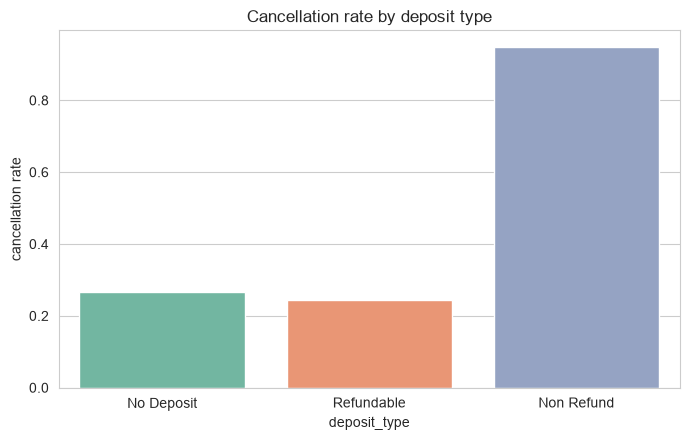

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=df, x="deposit_type", y="is_canceled", hue="deposit_type",
            errorbar=None, palette="Set2", legend=False, ax=ax)
ax.set_ylabel("cancellation rate")
ax.set_title("Cancellation rate by deposit type")
plt.tight_layout()
plt.show()


This is one of the most counter-intuitive findings in the whole dataset: bookings with a
**Non Refund** deposit cancel at a dramatically *higher* rate than bookings with **No Deposit**
at all — the opposite of what a naive intuition ("money on the line means people follow
through") would predict. In practice this pattern is well documented for this dataset: a
subset of non-refundable bookings appear to be entered by certain distributors in a way that
correlates strongly with subsequent cancellation in the source system. Whatever the true
mechanism, the takeaway for modeling is simple: `deposit_type` carries a very strong signal,
and it is a great example of why you should let the data challenge your assumptions rather
than the other way around.


In [8]:
fig = px.bar(
    df.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False).reset_index(),
    x="market_segment", y="is_canceled",
    title="Cancellation rate by market segment",
    labels={"is_canceled": "cancellation rate", "market_segment": "market segment"},
    color="is_canceled", color_continuous_scale="Reds",
)
fig.update_layout(height=450)
fig.show()


`market_segment` also separates cancellation behavior cleanly — segments like **Groups** show
elevated cancellation, while **Direct** and **Corporate** bookings (where the guest or a
company has a more direct, accountable relationship with the hotel) tend to cancel less. This
reinforces that *how* a booking was made is at least as predictive as *who* is making it or
*when* they are arriving.



## 6. Correlation heatmap of numeric features

A correlation heatmap gives a fast, if imperfect, overview of linear relationships among the
numeric columns and with the target. Tree-based models like Random Forest can capture
non-linear and interaction effects that a correlation coefficient completely misses — so treat
this as a first pass, not the final word.


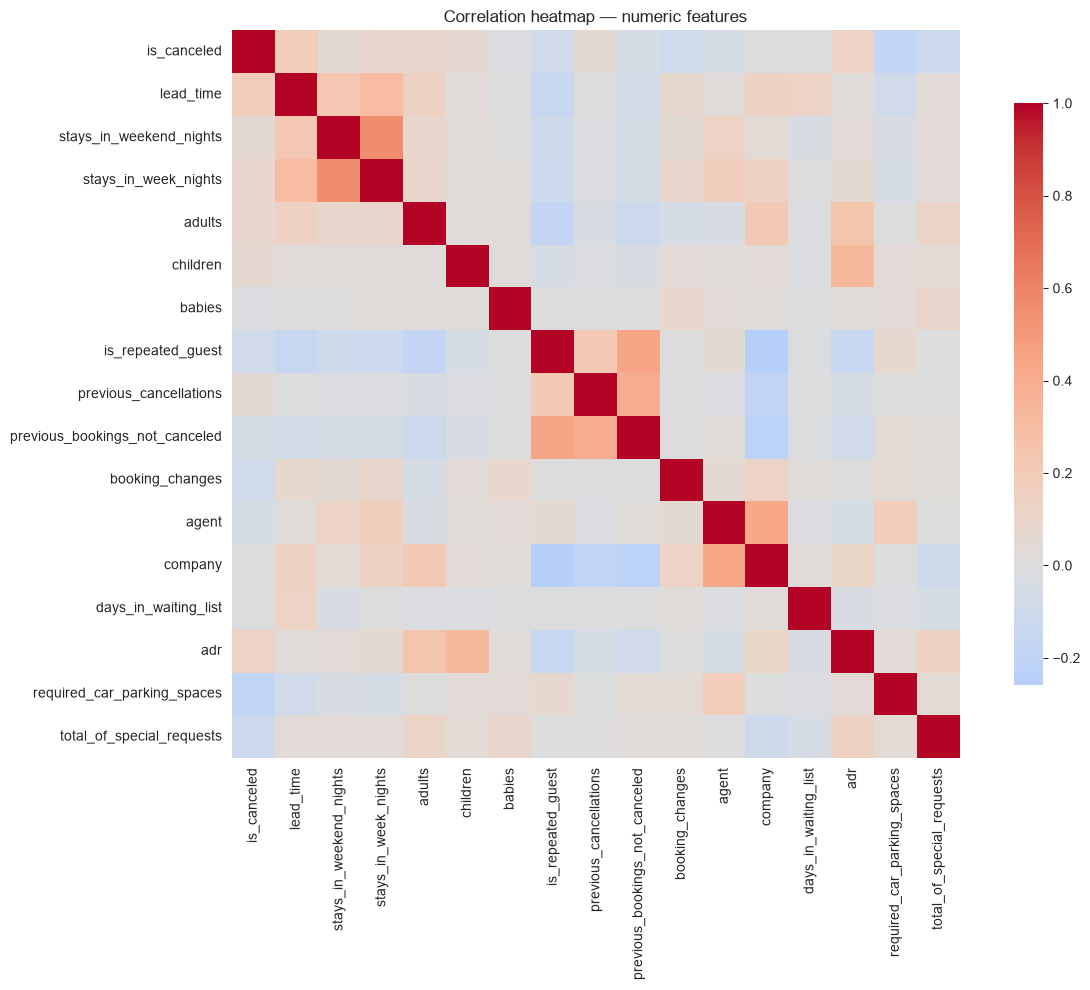

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067396
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
company                           0.009040
days_in_waiting_list              0.004464
babies                           -0.020543
agent                            -0.044359
previous_bookings_not_canceled   -0.052154
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Drop pure identifiers / low-value numeric codes that clutter the heatmap
drop_cols = [c for c in ["arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month"] if c in numeric_cols]
numeric_cols = [c for c in numeric_cols if c not in drop_cols]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()

corr["is_canceled"].sort_values(ascending=False)


Reading the last column against `is_canceled`:

- **`previous_cancellations`** and **`lead_time`** show the strongest positive correlation with
  cancellation — a guest who has canceled before, or who booked far ahead, is more likely to
  cancel again.
- **`total_of_special_requests`**, **`required_car_parking_spaces`**, and
  **`is_repeated_guest`** show negative correlation — guests who ask for specific
  accommodations or have parking needs, or who are repeat customers, tend to follow through.
  This makes intuitive sense: those actions signal a firmer, more concrete intent to actually
  show up.
- Most pairwise correlations among the features themselves are modest, which is reassuring —
  we don't have an obvious multicollinearity problem to worry about (though, again, trees
  don't care about multicollinearity the way linear models do).



## 7. An interactive view: hotel to market segment to outcome

Static bar charts are great for one or two categorical splits, but once we want to see three
levels of a hierarchy at once (hotel to market segment to cancellation outcome), an interactive
sunburst is much easier to read and explore than a stack of small subplots.


In [10]:
sunburst_df = df.groupby(["hotel", "market_segment", "is_canceled"]).size().reset_index(name="count")
sunburst_df["is_canceled"] = sunburst_df["is_canceled"].map({0: "Not canceled", 1: "Canceled"})

fig = px.sunburst(
    sunburst_df,
    path=["hotel", "market_segment", "is_canceled"],
    values="count",
    title="Hotel -> Market Segment -> Outcome",
    color="is_canceled",
    color_discrete_map={"Not canceled": "#4C72B0", "Canceled": "#C44E52", "(?)": "#CCCCCC"},
)
fig.update_layout(height=650)
fig.show()


Hover over any wedge in the rendered chart to see its exact count and share. This view makes
it easy to spot, for example, that within the City Hotel's "Online TA" segment (a large slice
of total volume) the canceled share is visually much thicker than the same segment's slice
under the Resort Hotel — the kind of interaction effect that a single 1-D bar chart would
hide.



## 8. Booking volume by country of origin


In [11]:
top_countries = df["country"].value_counts().head(15).reset_index()
top_countries.columns = ["country", "bookings"]

fig = px.bar(
    top_countries.sort_values("bookings"),
    x="bookings", y="country", orientation="h",
    title="Top 15 countries of origin by booking volume",
    color="bookings", color_continuous_scale="Blues",
)
fig.update_layout(height=550)
fig.show()


Bookings are heavily concentrated in a handful of countries (Portugal, the United Kingdom,
France, Spain, and Germany dominate), with a long tail of countries contributing only a
handful of bookings each. This high-cardinality, long-tailed structure is exactly why we will
use **frequency encoding** rather than one-hot encoding for `country` in the next notebook —
one-hot encoding a 170+ category column would explode the feature space with mostly-empty
columns for little predictive benefit.



## 9. What we learned, and what it means for modeling

- **`lead_time`** shows a clear, monotonic-looking relationship with cancellation risk —
  expect this to be one of the most important features in the trained forest.
- **`deposit_type`** carries a strong and counter-intuitive signal (`Non Refund` bookings
  cancel *more*, not less) — a great illustration of why EDA should challenge assumptions
  rather than just confirm them.
- **`market_segment`** and **`hotel`** meaningfully split cancellation behavior — both belong
  in the model, encoded as categoricals.
- Cancellation has a **seasonal component** by arrival month, once the categories are placed
  in the correct calendar order rather than alphabetical order.
- **`country`** is highly informative but extremely high-cardinality with a long tail — a
  frequency-encoding candidate, not a one-hot-encoding candidate.
- No single feature perfectly separates the classes (the correlation heatmap confirms this),
  which is exactly the setting where an ensemble of decision trees — a Random Forest — tends
  to shine: it can combine many moderately-informative features and their interactions in a
  way no single linear rule can.

With this understanding in hand, we move to `02_data_processing.ipynb` to handle the leakage
columns, fix missing values properly, engineer a couple of new features, and encode everything
for modeling.
